In [1]:
import sys
import os
# Add the parent directory (project root) to the path
# This allows us to import from src/
sys.path.insert(0, os.path.abspath('..'))
from src.data.loaders import (
    load_dataset_description,
    print_dataset_description,
    load_dataset_as_memmap,
    load_adj,
    load_dataset
)
from src.utils.visualization import plot_adjacency_matrix_heatmap

from src.utils import calculate_graph_metrics

# Quick test notebook for data loading module
# ============================================================================
# Test 1: Load and print dataset description
# ============================================================================
dataset = '../data/PEMS-BAY/'

print("="*70)
print("TEST 1: Loading dataset description")
print("="*70)

print_dataset_description(dataset)

# ============================================================================
# Test 2: Load time series data
# ============================================================================

print("\n" + "="*70)
print("TEST 2: Loading time series data")
print("="*70)

data, success = load_dataset_as_memmap(dataset)

if success:
    print(f"✓ Data loaded successfully!")
    print(f"  Shape: {data.shape}")
    print(f"  Dtype: {data.dtype}")
    print(f"  Sample values (first 5 timesteps, first 3 nodes):")
    print(data[:5, :3, 0])
else:
    print("✗ Failed to load data")

# ============================================================================
# Test 3: Load adjacency matrix with different preprocessing
# ============================================================================

print("\n" + "="*70)
print("TEST 3: Loading adjacency matrix")
print("="*70)

adj_types_to_test = ['original', 'doubletransition', 'identity']

for adj_type in adj_types_to_test:
    try:
        adj, adj_mx = load_adj(dataset + 'adj_mx.pkl', adj_type)
        print(f"\n✓ '{adj_type}' loaded successfully")
        print(f"  Number of matrices: {len(adj)}")
        print(f"  Shape of each: {[a.shape for a in adj]}")
        print(f"  Raw adjacency shape: {adj_mx.shape}")
        print(f"  Sample values from processed matrix:")
        print(adj[0][:3, :3])
    except Exception as e:
        print(f"\n✗ '{adj_type}' failed: {e}")

# ============================================================================
# Test 4: Load complete dataset at once
# ============================================================================

print("\n" + "="*70)
print("TEST 4: Loading complete dataset")
print("="*70)

dataset_dict = load_dataset(
    dataset, adj_type='doubletransition', verbose=False)

print(f"Keys in dataset: {list(dataset_dict.keys())}")
if 'data' in dataset_dict:
    print(f"✓ Data shape: {dataset_dict['data'].shape}")
if 'adj' in dataset_dict:
    print(f"✓ Adjacency matrices: {len(dataset_dict['adj'])}")
if 'metadata' in dataset_dict:
    print(f"✓ Metadata loaded: {dataset_dict['metadata']['name']}")

# ============================================================================
# Test 5: Your specific use case
# ============================================================================

print("\n" + "="*70)
print("TEST 5: Your specific requirement")
print("="*70)

adj, adj_mx = load_adj(dataset + 'adj_mx.pkl', 'doubletransition')

print(f"✓ Successfully loaded doubletransition adjacency!")
print(f"  Type: {type(adj)}")
print(f"  Length: {len(adj)}")
print(f"  Matrix 1 shape: {adj[0].shape}")
print(f"  Matrix 2 shape: {adj[1].shape}")
print(f"  Raw adjacency shape: {adj_mx.shape}")

print("\n" + "="*70)
print("ALL TESTS COMPLETED!")
print("="*70)


print("\n"+"="*70+"\n")
print(calculate_graph_metrics(adj_mx))


TEST 1: Loading dataset description
--- Dataset Description ---
Dataset Name: PEMS-BAY
Domain: traffic speed
Number of Time Slices: 52116
Number of Nodes (Time Series): 325
Number of features per Node: 3

--- Feature and Structure ---
Features description: traffic speed, time of day, day of week
Time step length: 5 minutes
Prior Graph Structures: Present

--- Model Settings ---
Input Sequence Length: 12
Output Sequence Length: 12
Training Data Ratio: 0.7
Validation Data Ratio: 0.1
Test Data Ratio: 0.2
Individual Channel Normalization: No
Renormalize during Evaluation: Yes
Evaluation Metrics: MAE, RMSE, MAPE
Outlier Handling: 0.0

TEST 2: Loading time series data
Attempting to load data with shape [52116, 325, 3]...
Data loaded successfully as a numpy.memmap object.
Data shape: (52116, 325, 3)
✓ Data loaded successfully!
  Shape: (52116, 325, 3)
  Dtype: float32
  Sample values (first 5 timesteps, first 3 nodes):
[[71.4 67.8 70.5]
 [71.6 67.5 70.6]
 [71.6 67.6 70.2]
 [71.1 67.5 70.3]
 [

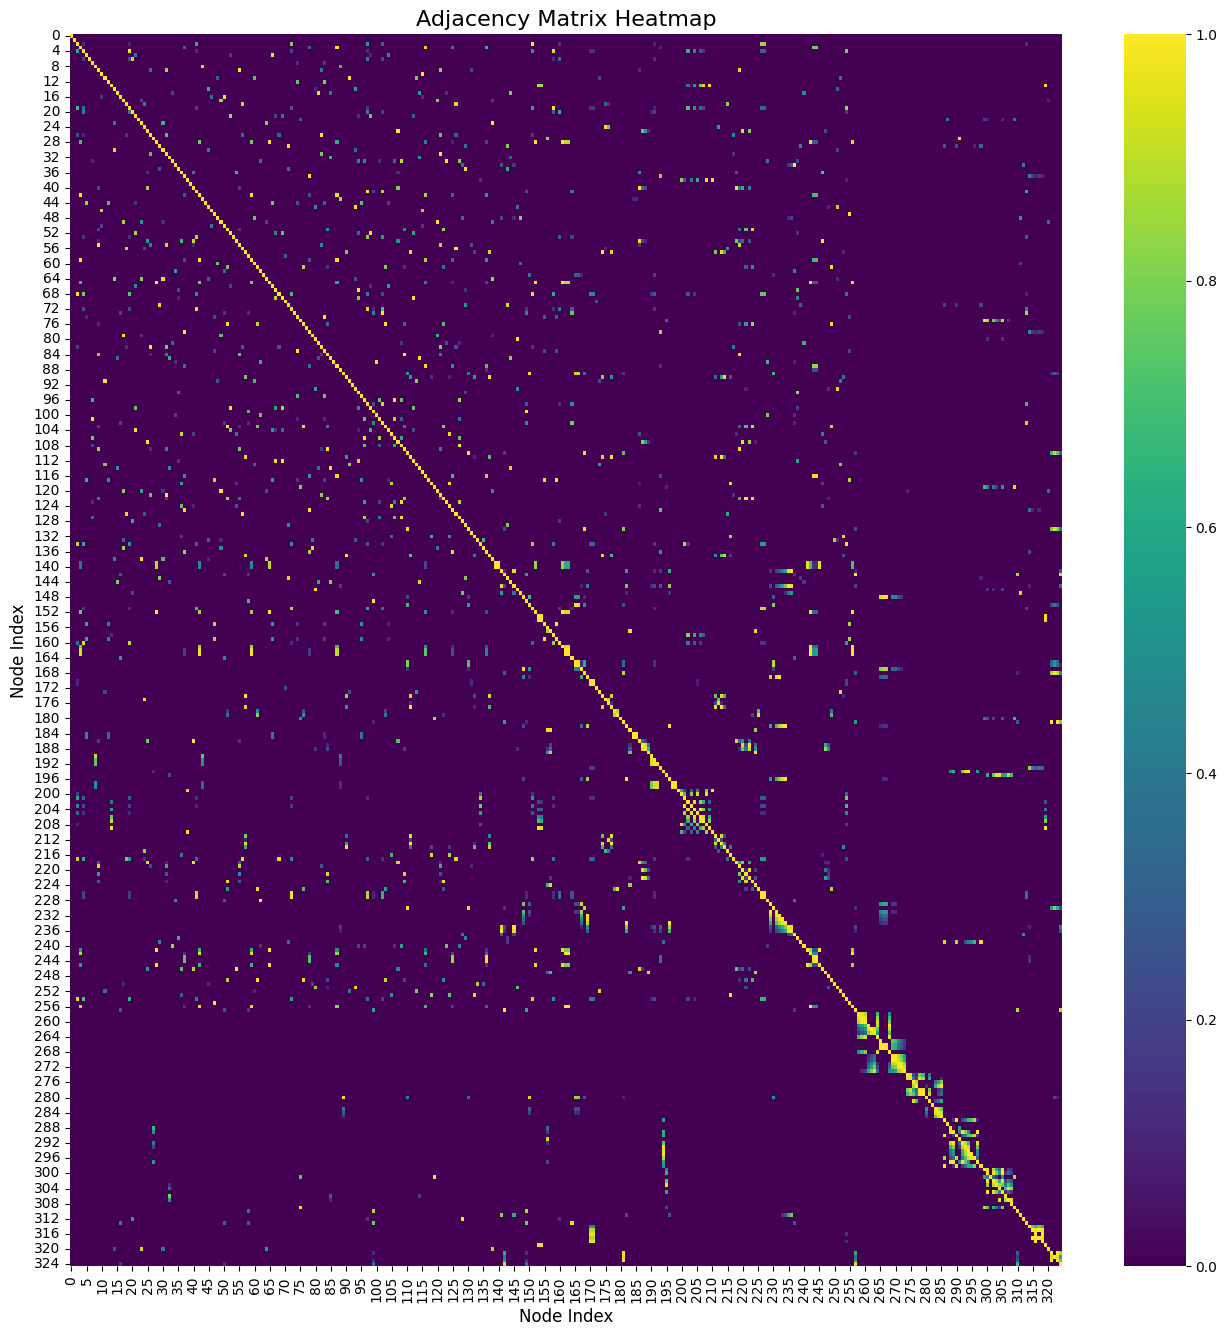

In [2]:
from src.utils.visualization import (
    plot_adjacency_matrix_heatmap,
    draw_graph_network,
    draw_graph_communities,
    draw_graph_components,
    draw_graph_with_hubs,
    plot_degree_distribution,
    compare_adjacency_matrices_heatmap,
    plot_node_time_series,
    plot_time_series_decomposition,
)
from src.utils.graph_metrics import (
    calculate_graph_metrics,
    compare_adjacency_matrices
)
plot_adjacency_matrix_heatmap(adj_mx)

In [3]:
train_data = data[:int(len(data)*0.7), :, :]

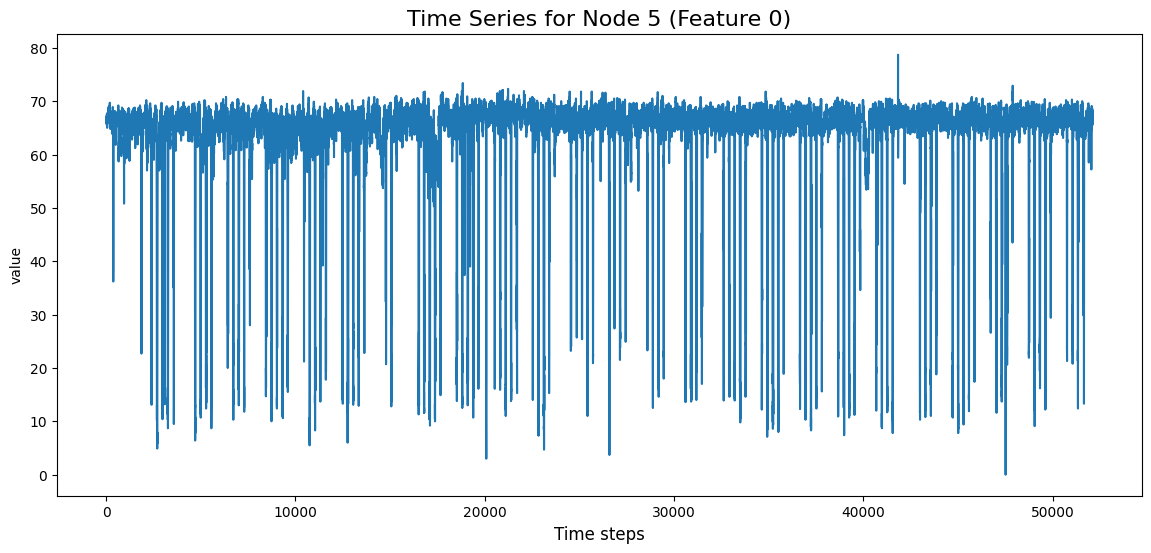

In [4]:
plot_node_time_series(data, 5)

In [5]:
from src.matrix_generation import PearsonCorrelationGenerator

In [6]:
pearson = PearsonCorrelationGenerator(0)
corr = pearson.generate(train_data)

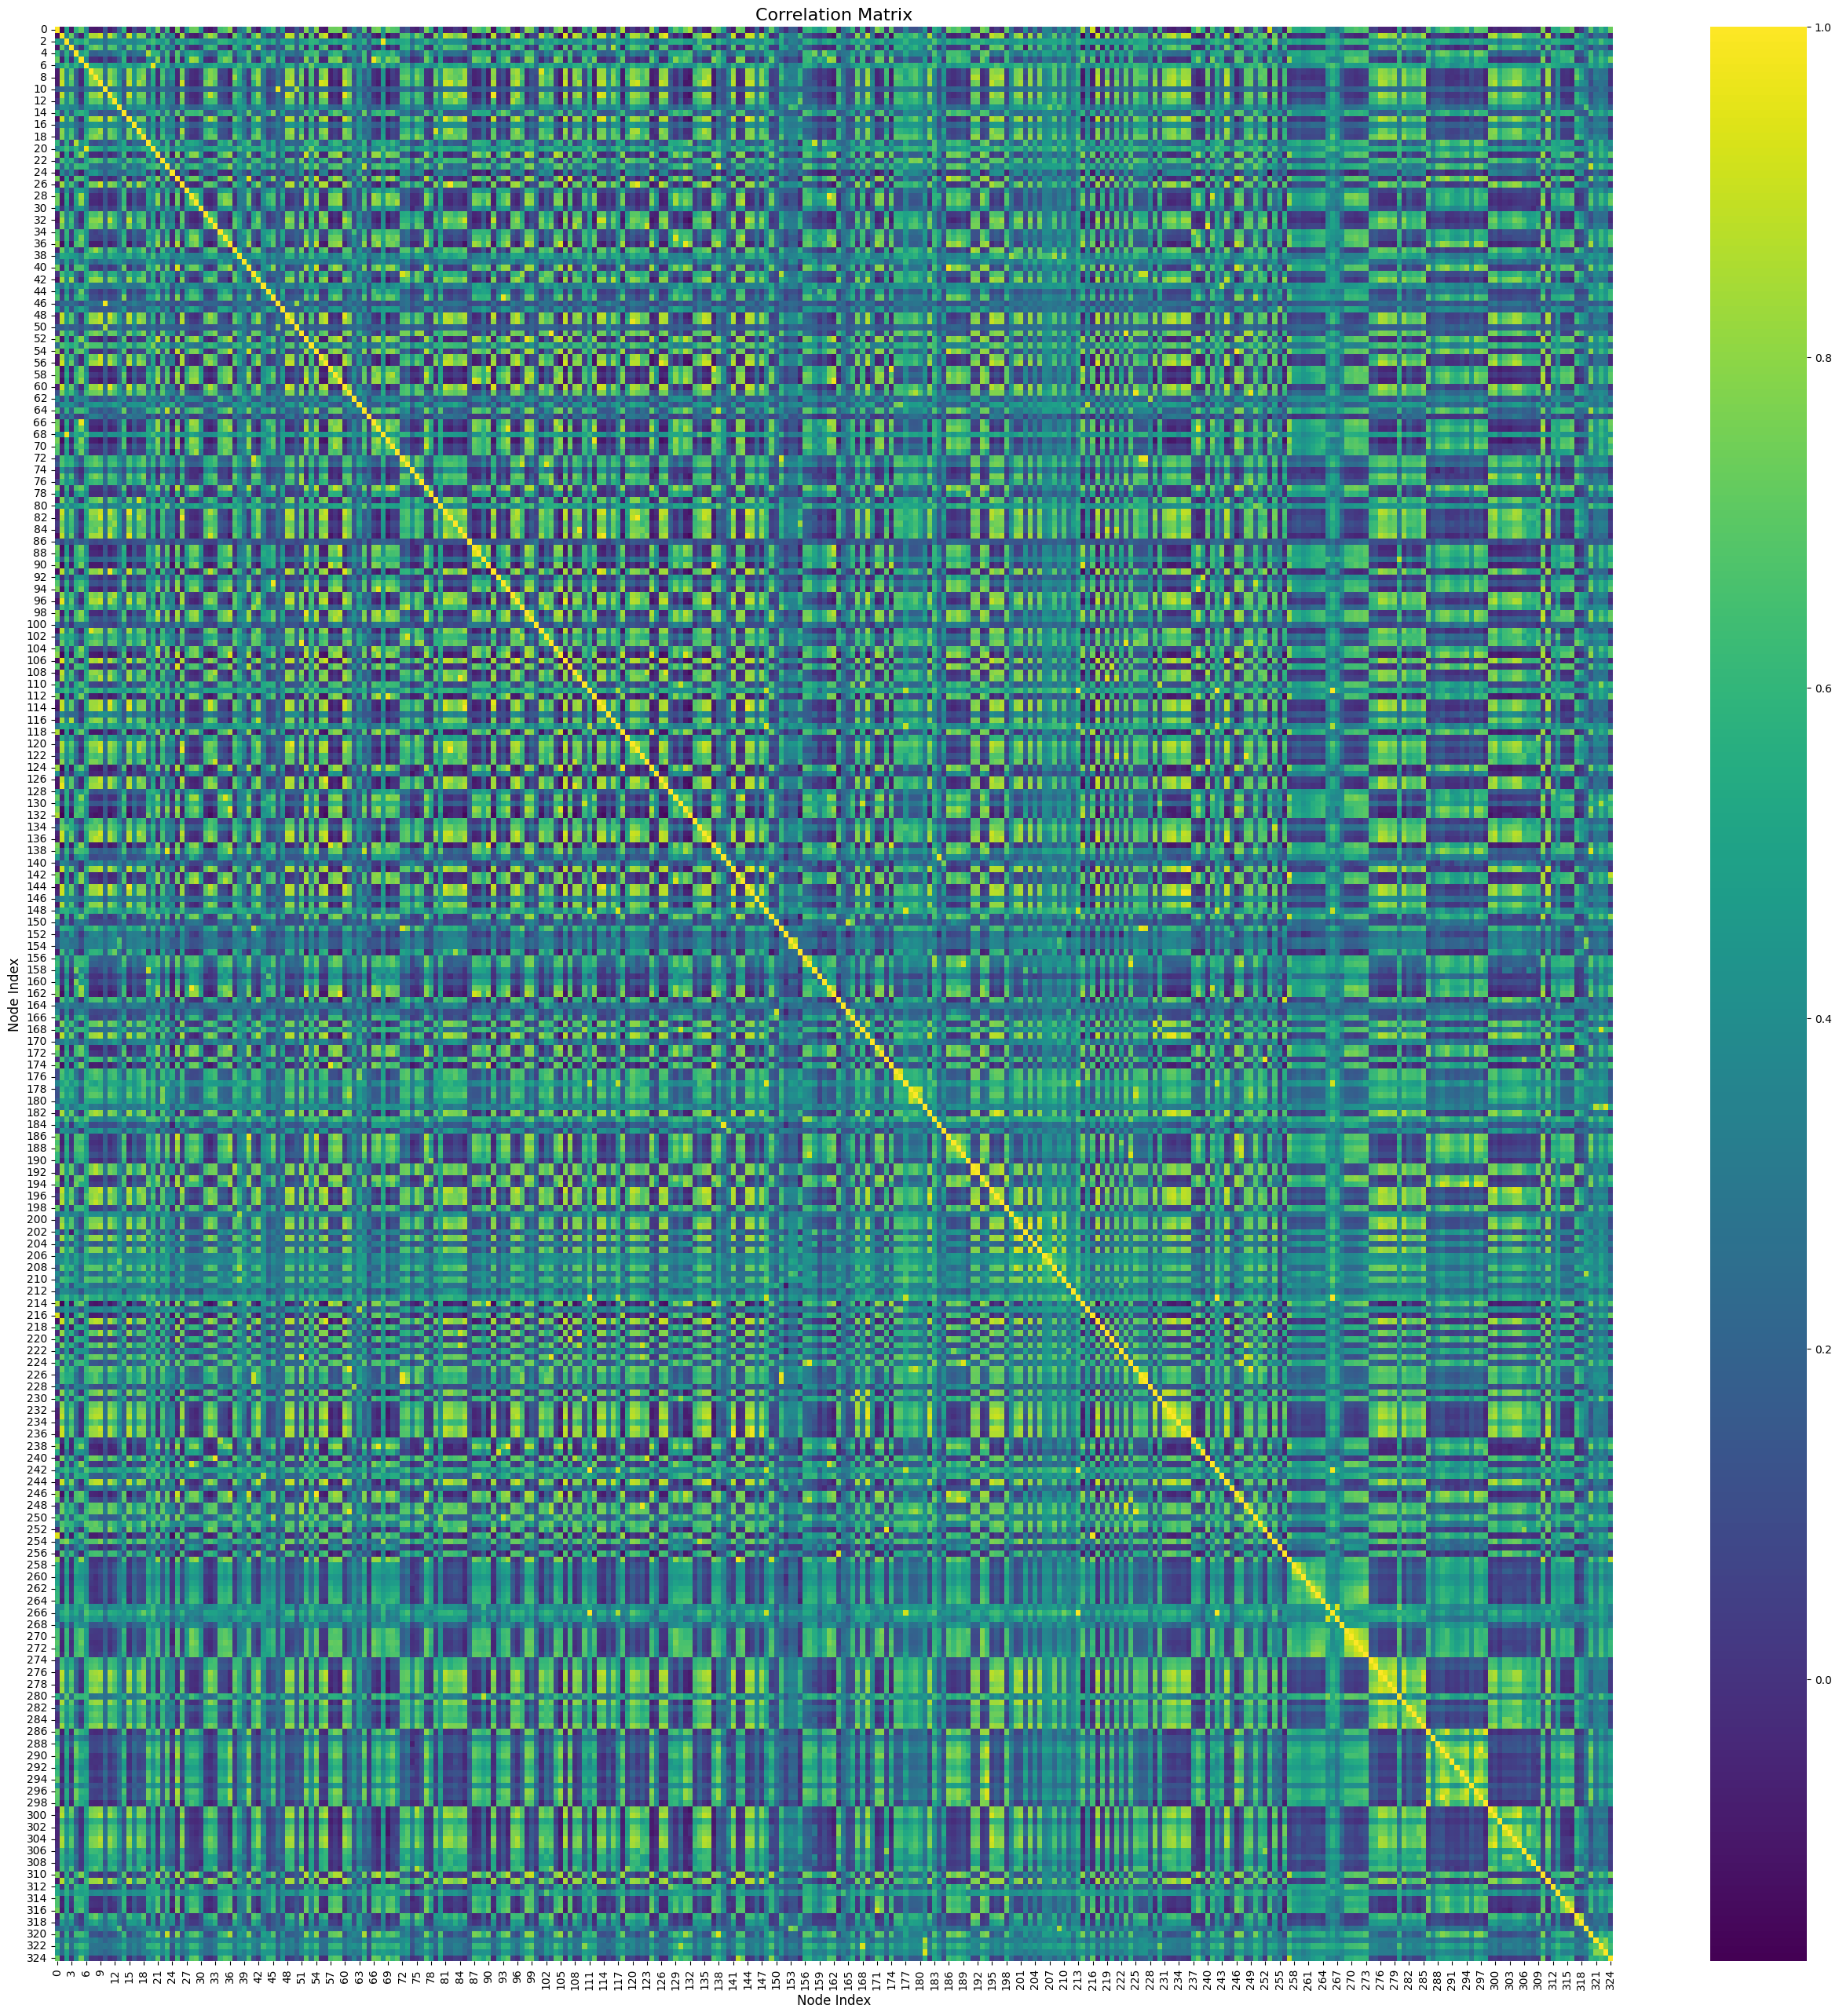

In [7]:
plot_adjacency_matrix_heatmap(corr, "Correlation Matrix", figsize=(32,32))

In [8]:
from src.sparcification import make_adjacency_matrix

mtr = (make_adjacency_matrix(corr, 2694, 'top-k-row', fill_diag=True))

In [9]:
from src.data.loaders import save_pkl, load_pkl

In [13]:
for method in ['top-k-row', 'top-k-global', 'greedy-degree-regularize',
               'threshold-mask', 'spectral-sparce', 'strict-spectral-sparce',
               'top-k-row-global-limit', 'dhont-corr-sum', 'dhont-top-edge']:
    for i in range(3):
        k = 2694
        if method == 'spectral-sparce':
            k=k//2
        res_matrix = make_adjacency_matrix(corr, k, mask=method, fill_diag=True)
        save_pkl(res_matrix,f'../results/{method}_{i+1}.pkl')
        print('-'*80, '\n', f'Method: {method}, iter {i+1}\n', calculate_graph_metrics(res_matrix))

Object successfully saved to ../results/top-k-row_1.pkl
-------------------------------------------------------------------------------- 
 Method: top-k-row, iter 1
 {'num_nodes': 325, 'total_edges': 2600, 'density': 0.024691358024691357, 'avg_connection_strength': 0.8148779273033142, 'clustering_coefficient': 0.0002123374465995725, 'min_degree': 9, 'max_degree': 42, 'mean_degree': 16.0, 'median_degree': 14.0, 'mode_degree': 12, 'std_degree': 6.093628450464279, 'q1_degree': 12.0, 'q3_degree': 19.0, 'reciprocity': 0.2673076923076923, 'mean_in_degree': 8.0, 'mean_out_degree': 8.0}
Object successfully saved to ../results/top-k-row_2.pkl
-------------------------------------------------------------------------------- 
 Method: top-k-row, iter 2
 {'num_nodes': 325, 'total_edges': 2600, 'density': 0.024691358024691357, 'avg_connection_strength': 0.8148779273033142, 'clustering_coefficient': 0.0002123374465995725, 'min_degree': 9, 'max_degree': 42, 'mean_degree': 16.0, 'median_degree': 14.0, 